In [ ]:
"""
ID :- 24DCE010
"""


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import  StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score,
     recall_score, f1_score,
    classification_report, confusion_matrix,
     ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

In [70]:
df = pd.read_csv(r"C:\Users\dipal\Downloads\Heart Disease Dataset.csv");

In [71]:


print("Dataset shape:", df.shape)
print()
print("Attributes:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)





Dataset shape: (1025, 14)

Attributes:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [ ]:
print("\nDataset information:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print(" Q1 :- in above cell output i show the structure,"
 "size, attributes, and data types of my fream.")


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1016 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     9
slope       0
ca          0
thal        0
target

In [73]:


print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

invalid_values = ["NA", "null", "None", ""]
df = df.replace(invalid_values, np.nan)





Duplicate rows: 714


In [ ]:
print("\nData after removing duplicates:", df.shape)
print("\nMissing values after removing duplicates:")
print(df.isnull().sum())


print("Missing values were handled using median imputation"
" for numerical attributes and most-frequent imputation for" 
"categorical attributes.")



Data after removing duplicates: (311, 14)

Missing values after removing duplicates:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     9
slope       0
ca          0
thal        0
target      0
dtype: int64
Missing values were handled using median imputation for numerical attributes and most-frequent imputation for categorical attributes.


In [ ]:

target_candidates = ["target", "Target", "HeartDisease"
, "heart_disease", "output", "condition"]

target_col = next(
    (column for column in target_candidates if column in df.columns),
    df.columns[-1]
)

print("\nTarget column:", target_col)

target_values = df[target_col].astype(str)

target_mapping = {
    "yes": 1,
    "no": 0,
    "presence": 1,
    "absence": 0,
    "positive": 1,
    "negative": 0,
    "true": 1,
    "false": 0,
    "disease": 1,
    "normal": 0
}



Target column: target


In [ ]:

if target_values.isin(target_mapping).all():
    df[target_col] = target_values.map(target_mapping)
else:
    numeric_target = pd.to_numeric(
        df[target_col], errors="coerce")

    if numeric_target.notna().all():
        unique_values = sorted(numeric_target.unique())

        if len(unique_values) == 2:
            df[target_col] = numeric_target.map(
                {unique_values[0]: 0, unique_values[1]: 1}
            )
        else:
            df[target_col] = numeric_target
    else:
        df[target_col] = pd.factorize(target_values)[0]

df = df.dropna(subset=[target_col])


In [ ]:

print("\nStatistical summary:")
print(df.describe(include=[np.number]))

print("\nTarget distribution:")
print(df[target_col].value_counts())

print("\nTarget proportions:")
print(df[target_col].value_counts(normalize=True))

print("Q3 :- Generate appropriate statistical"
" summaries of the numerical attributes.")





Statistical summary:
              age         sex          cp    trestbps        chol         fbs  \
count  311.000000  311.000000  311.000000  311.000000  311.000000  311.000000   
mean    54.418006    0.681672    0.954984  131.575563  245.935691    0.144695   
std      9.160867    0.466578    1.027634   17.488243   51.855466    0.352360   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  210.500000    0.000000   
50%     56.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  311.000000  311.000000  311.000000  302.000000  311.000000  311.000000   
mean     0.517685  149.572347    0.324759    1.043046    1.389068    0.717042   
std  

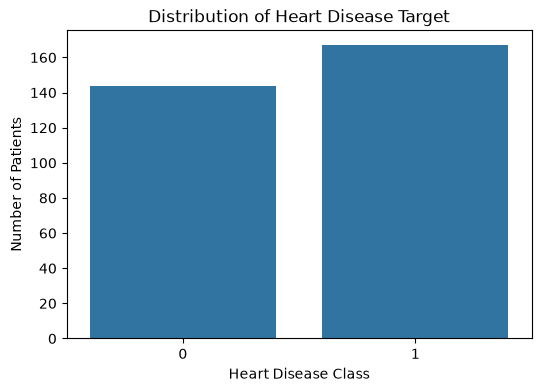

Q4 :- hear we are generate bar chart for distribution of the target variable 


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col)
plt.title("Distribution of Heart Disease Target")
plt.xlabel("Heart Disease Class")
plt.ylabel("Number of Patients")
plt.show()

print("Q4 :- hear we are generate bar chart "
"for distribution of the target variable ")

hear we are select two numeric column to predicate the our result. 


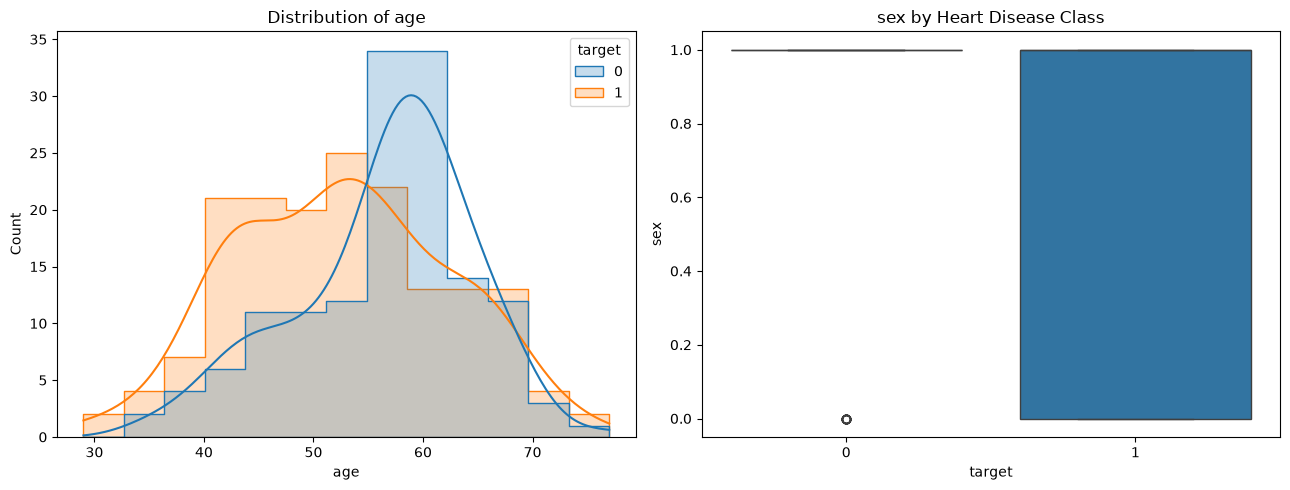

age and sex were selected because they are commonly releated with high riskof disease.


In [ ]:


print("hear we are select two numeric column"
" to predicate the our result. ")

numeric_columns = df.drop(columns=[target_col]).select_dtypes(
    include=np.number
).columns.tolist()

feature_one = "Age" if "Age" in df.columns else numeric_columns[0]
feature_two = "Chol" if "Chol" in df.columns else numeric_columns[1]



fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    data=df,
    x=feature_one,
    hue=target_col,
    kde=True,
    element="step",
    ax=axes[0]
)
axes[0].set_title(f"Distribution of {feature_one}")

sns.boxplot(
    data=df,
    x=target_col,
    y=feature_two,
    ax=axes[1]
)
axes[1].set_title(f"{feature_two} by Heart Disease Class")

plt.tight_layout()
plt.show()

print("age and sex were selected because they"
" are commonly releated with high riskof disease.")


In [ ]:

X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

numeric_features = X.select_dtypes(
    include=np.number).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number).columns.tolist()


numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
("imputer", SimpleImputer(strategy="most_frequent")),
("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("hear i am spliting the dataset in two parts,"
" one part is to train the model and another part to"
" test the model.")


hear i am spliting the dataset in two parts, one part is to train the model and another part to test the model.


In [ ]:

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, 
y_pred, zero_division=0)

recall = recall_score(y_test, 
y_pred, zero_division=0)

f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_probability)


In [82]:

print("\nModel Performance")
print("Accuracy :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall :", round(recall, 4))
print("F1-score :", round(f1, 4))




Model Performance
Accuracy : 0.7937
Precision : 0.7692
Recall : 0.8824
F1-score : 0.8219



Classification :
              precision    recall  f1-score   support

           0       0.83      0.69      0.75        29
           1       0.77      0.88      0.82        34

    accuracy                           0.79        63
   macro avg       0.80      0.79      0.79        63
weighted avg       0.80      0.79      0.79        63



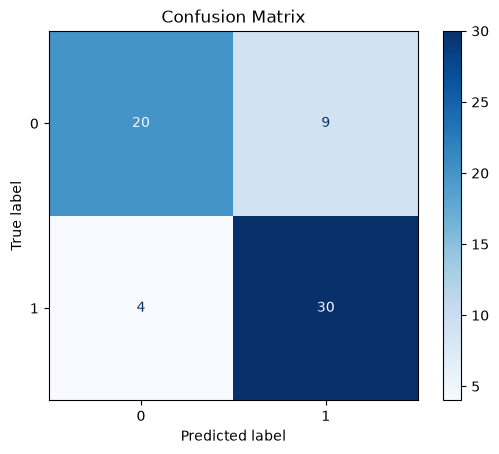

In [ ]:

print("\nClassification :")
print(classification_report(y_test, 
y_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix")
plt.show()


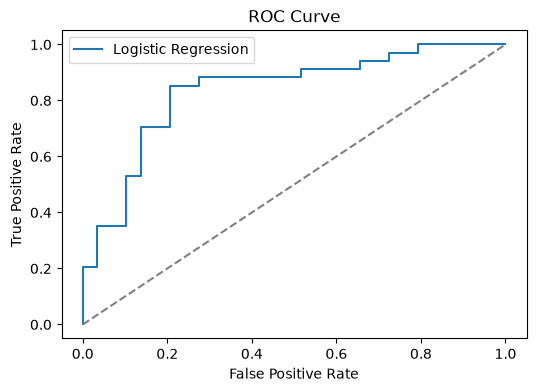

In [84]:

false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(6, 4))
plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Logistic Regression"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [85]:

unseen_pred = X_test.copy()
unseen_pred["Actual"] = y_test.values
unseen_pred["Predicted"] = y_pred
unseen_pred["Probability_of_Disease"] = y_probability

print("\nPredictions on unseen data:")
print(unseen_pred.head(10))




Predictions on unseen data:
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
268   69    1   2       140   254    0        0      146      0      2.0   
24    61    0   0       145   307    0        0      146      1      1.0   
118   63    0   0       124   197    0        1      136      1      0.0   
33    46    1   2       150   231    0        1      147      0      3.6   
303   64    1   2       140   335    0        1      158      0      0.0   
244   46    0   2       142   177    0        0      160      1      1.4   
54    67    1   2       152   212    0        0      150      0      0.8   
59    59    1   2       150   212    1        1      157      0      1.6   
81    54    0   2       108   267    0        0      167      0      0.0   
131   67    0   2       115   564    0        0      160      0      1.6   

     slope  ca  thal  Actual  Predicted  Probability_of_Disease  
268      1   3     3       0          0                0.019710  
24

In [ ]:
print("summary explaining the overall findings, "
"model performance, and one limitation of your analysis")

"""

in my practical first i will load te dataset of heart disease dataset
and i will check first staticial information andi will start to 
analysis of my dataset.

after to load the dataset i will check number of rows and column and
also check the is there any null value or not.

i my dataset i have only 9 null values i will delete those rows
because that very lesss number of rows in compare of total rows.

after that i select two numeric columns to predicate our result which
 are age and sex. i chose those value bacause those values are more 
 correlated inc ompare of others.

after the fetaure selection i will split my data set into two prats.
 i divide my dataset in two parts 20% for testing and 80% for train 
 model.

after spliting the data into two parts i implement the linear 
regression to predicate result.

then after i plot confusion metrix for my model. 







"""

summary explaining the overall findings, model performance, and one limitation of your analysis


'\n\nin my practical first i will load te dataset of heart disease dataset and i will check first staticial information andi will start to analysis of my dataset.\n\nafter to load the dataset i will check number of rows and column and also check the is there any null value or not.\n\ni my dataset i have only 9 null values i will delete those rows because that very lesss number of rows in compare of total rows.\n\nafter that i select two numeric columns to predicate our result which are age and sex. i chose those value bacause those values are more correlated inc ompare of others.\n\nafter the fetaure selection i will split my data set into two prats. i divide my dataset in two parts 20% for testing and 80% for train model.\n\nafter spliting the data into two parts i implement the linear regression to predicate result.\n\nthen after i plot confusion metrix for my model. \n\n\n\n\n\n\n\n'